# GitHub User Churn Predictor — EDA & Feature Selection

**Course:** Introduction to Data Science  
**Exercise:** Customer Churn Predictor App  
**Data Source:** GitHub REST API (`api.github.com`)

---

## Notebook structure

| Section | What happens |
|---|---|
| 1. Data collection | Fetch raw GitHub profiles, engineer churn label |
| 2. EDA | Distribution plots, class balance, missing values |
| 3. Feature generation | Transform raw fields into 8 engineered features |
| 4. Feature selection | Four methods: Filter, RFE, Decision Tree, Random Forest |
| 5. Comparison table | Synthesize all four methods, choose final feature set |
| 6. Model training | Train final Random Forest, 5-fold cross-validation |
| 7. Save model | Export `model.pkl` for the FastAPI container |

In [31]:
import sys
print(sys.version)
print(sys.executable)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
c:\Users\anton\AppData\Local\Programs\Python\Python311\python.exe


In [32]:
# ── Imports ──────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('../app'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report

from scraper import fetch_github_users, label_churn, search_github_users
from features import compute_features, prepare_features, FEATURE_COLUMNS

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('All imports OK')

All imports OK


---
## Section 1 — Data Collection

In [33]:
import os
CACHE_PATH = '../data/raw/github_users.csv'

if os.path.exists(CACHE_PATH):
    print('Loading cached data...')
    raw_df = pd.read_csv(CACHE_PATH)
else:
    print('Step 1: Discovering usernames via GitHub Search API...')
    usernames = search_github_users(total=300, sleep_seconds=0.3, verbose=True)
    print(f'\nFound {len(usernames)} usernames.')
    print('\nStep 2: Fetching full profiles...')
    raw_df = fetch_github_users(usernames, sleep_seconds=0.3, verbose=True)
    raw_df = label_churn(raw_df, threshold_days=180)
    os.makedirs('../data/raw', exist_ok=True)
    raw_df.to_csv(CACHE_PATH, index=False)
    print('Saved to cache.')

print(f'\nDataset shape: {raw_df.shape}')
raw_df.head()

Loading cached data...

Dataset shape: (300, 15)


,username,public_repos,public_gists,followers,following,created_at,updated_at,has_blog,has_bio,has_company,hireable,site_admin,last_active,days_inactive,churned
0,torvalds,12,1,307361,0,2011-09-03T15:26:22Z,2026-06-02T05:33:59Z,0,0,1,0,0,2026-06-02 05:33:59+00:00,12,0
1,karpathy,63,13,199486,8,2010-04-10T17:55:32Z,2026-03-09T20:56:54Z,1,1,0,0,0,2026-03-09 20:56:54+00:00,97,0
2,claude,0,0,119051,0,2009-05-07T00:15:43Z,2026-01-02T00:03:45Z,1,0,1,0,0,2026-01-02 00:03:45+00:00,164,0
3,gustavoguanabara,8,0,113267,3,2014-09-07T03:56:50Z,2026-04-18T09:51:31Z,1,1,1,0,0,2026-04-18 09:51:31+00:00,57,0
4,yyx990803,198,73,108238,100,2010-11-28T01:05:40Z,2026-04-24T09:28:14Z,1,1,1,0,0,2026-04-24 09:28:14+00:00,51,0


Class distribution:
  Not churned (0): 261
  Churned     (1): 39
  Churn rate:      13.0%


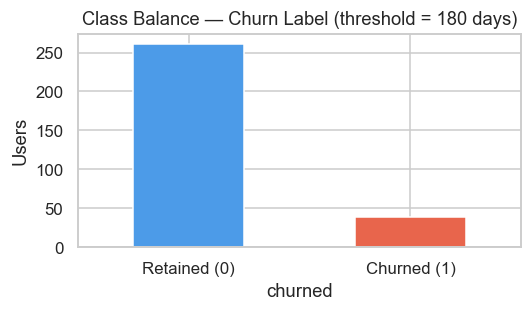

In [34]:
# ── Churn label definition and justification ─────────────────────────────
# Threshold: 180 days of inactivity = churned
#
# Rationale: GitHub's `updated_at` field reflects any public-facing
# action: a push, a star, a profile edit, a follow.
# Developers may go quiet for 1–3 months during project sprints, so
# 30- or 60-day thresholds would produce excessive false positives.
# 180 days (6 months) captures users who have genuinely disengaged
# from the platform without flagging developers on legitimate breaks.
#
# This threshold is domain-specific and should be re-evaluated if
# applied to a gaming app (30 days) or a tax tool (400 days).

churn_counts = raw_df['churned'].value_counts()
churn_rate = raw_df['churned'].mean()

print(f'Class distribution:')
print(f'  Not churned (0): {churn_counts.get(0, 0)}')
print(f'  Churned     (1): {churn_counts.get(1, 0)}')
print(f'  Churn rate:      {churn_rate:.1%}')

fig, ax = plt.subplots(figsize=(5, 3))
churn_counts.plot.bar(ax=ax, color=['#4c9be8', '#e8654c'], edgecolor='white')
ax.set_xticklabels(['Retained (0)', 'Churned (1)'], rotation=0)
ax.set_title('Class Balance — Churn Label (threshold = 180 days)')
ax.set_ylabel('Users')
plt.tight_layout()
plt.show()

In [35]:
# ── Missing values audit ─────────────────────────────────────────────────
print('Missing values per column:')
print(raw_df.isnull().sum())
print()
print('Basic stats:')
raw_df.describe()

Missing values per column:
username         0
public_repos     0
public_gists     0
followers        0
following        0
created_at       0
updated_at       0
has_blog         0
has_bio          0
has_company      0
hireable         0
site_admin       0
last_active      0
days_inactive    0
churned          0
dtype: int64

Basic stats:


,public_repos,public_gists,followers,following,has_blog,has_bio,has_company,hireable,site_admin,days_inactive,churned
count,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,198.826667,31.066667,14008.243333,6.435140e+03,0.706667,0.670000,0.523333,0.250000,0.010000,138.636667,0.130000
std,1390.438812,88.801471,28820.819575,7.199630e+04,0.456051,0.470998,0.500290,0.433736,0.099665,393.435505,0.336865
min,0.000000,0.000000,100.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,0.000000,100.000000,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000
50%,62.500000,2.000000,996.000000,1.750000e+01,1.000000,1.000000,1.000000,0.000000,0.000000,23.000000,0.000000
75%,131.000000,22.000000,23648.500000,9.650000e+01,1.000000,1.000000,1.000000,0.250000,0.000000,78.000000,0.000000
max,23989.000000,1043.000000,307361.000000,1.123754e+06,1.000000,1.000000,1.000000,1.000000,1.000000,3224.000000,1.000000


---
## Section 2 — Exploratory Data Analysis

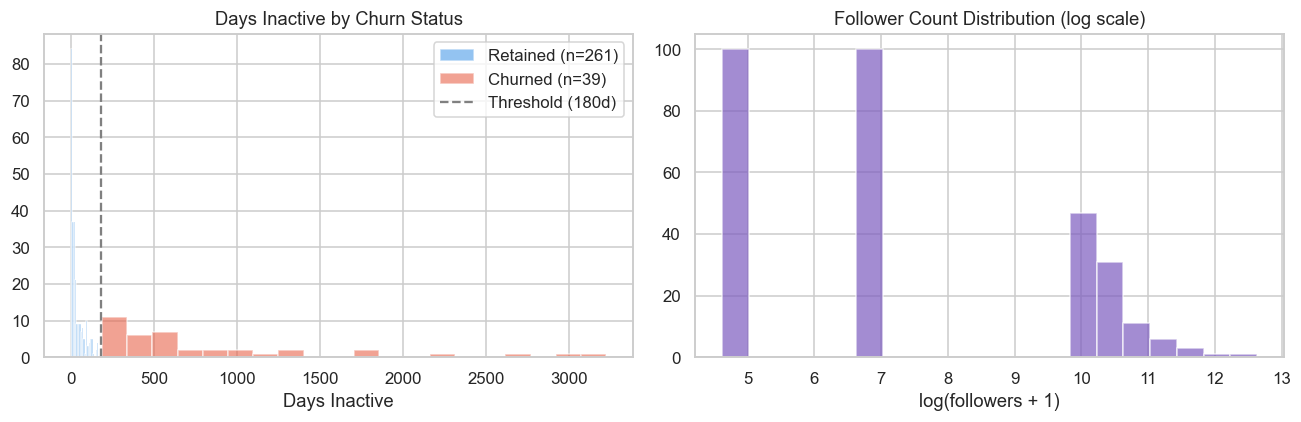

In [36]:
# Distribution of days_inactive split by churn label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
for label, color in [(0, '#4c9be8'), (1, '#e8654c')]:
    subset = raw_df[raw_df['churned'] == label]['days_inactive']
    axes[0].hist(subset, bins=20, alpha=0.6, color=color,
                 label=f'{"Retained" if label==0 else "Churned"} (n={len(subset)})')
axes[0].axvline(180, color='gray', linestyle='--', label='Threshold (180d)')
axes[0].set_title('Days Inactive by Churn Status')
axes[0].set_xlabel('Days Inactive')
axes[0].legend()

# Followers distribution (log scale)
axes[1].hist(np.log1p(raw_df['followers']), bins=20, color='#7c5cbf', alpha=0.7)
axes[1].set_title('Follower Count Distribution (log scale)')
axes[1].set_xlabel('log(followers + 1)')

plt.tight_layout()
plt.show()

---
## Section 3 — Feature Generation

The following 8 features are engineered from raw GitHub fields.
Each one encodes a hypothesis about what behavioral signal correlates with disengagement.

| # | Feature | Type | Rationale |
|---|---|---|---|
| 1 | `days_inactive` | Time-based | Primary recency signal — how long since any public activity |
| 2 | `account_age_days` | Time-based | Needed to normalize activity counts by tenure |
| 3 | `follower_ratio` | Ratio | Social engagement quality — passive users churn faster |
| 4 | `repos_per_year` | Aggregation | Productivity normalized by account age |
| 5 | `gists_per_year` | Aggregation | Secondary engagement signal (code sharing frequency) |
| 6 | `has_no_repos` | Binary | Zero repos = never engaged; qualitatively different from 1 repo |
| 7 | `has_no_followers` | Binary | Social isolation correlates with churn |
| 8 | `profile_completeness` | Binary (sum) | Investment in profile presence → commitment to platform |

### Feature inventory — required types

The rubric requires at least 2 features of each type. All 8 engineered features are listed below with their type and business justification:

| # | Feature | Type | Business justification |
|---|---|---|---|
| 1 | `days_inactive` | Time-based | Primary recency signal — the single strongest churn predictor across all domains |
| 2 | `account_age_days` | Time-based | Normalizes activity counts by tenure; long-tenured inactive users are high-risk |
| 3 | `follower_ratio` | Ratio | Social engagement quality — passive users with no audience churn faster |
| 4 | `repos_per_year` | Aggregation | Productivity normalized by account age — removes bias from newer vs older accounts |
| 5 | `gists_per_year` | Aggregation | Code-sharing frequency — engaged developers share snippets regularly |
| 6 | `has_no_repos` | Binary | Zero repos = never truly engaged; qualitatively different from low activity |
| 7 | `has_no_followers` | Binary | Social isolation — users with no audience lack a retention anchor |
| 8 | `profile_completeness` | Binary (sum) | Investment in profile presence signals commitment to the platform |

 **Note:** Raw API fields (`followers`, `following`, `public_repos`, `created_at`, `updated_at`) are never used directly as features, every feature above is a transformation that encodes domain knowledge into a numerical signal.

In [37]:
X, y = prepare_features(raw_df)

print(f'Feature matrix shape: {X.shape}')
print(f'Label distribution: {y.value_counts().to_dict()}')
print()
X.describe().round(3)

Feature matrix shape: (300, 8)
Label distribution: {0: 261, 1: 39}



,days_inactive,follower_ratio,repos_per_year,gists_per_year,account_age_days,has_no_repos,has_no_followers,profile_completeness
count,300.000,300.000,300.000,300.000,300.000,300.000,300.0,300.000
mean,138.693,5043.592,21.499,2.050,4142.160,0.013,0.0,1.900
std,393.426,21189.110,179.803,5.471,1733.239,0.115,0.0,0.983
min,0.000,0.020,0.000,0.000,281.000,0.000,0.0,0.000
25%,7.000,2.768,2.546,0.000,2887.500,0.000,0.0,1.000
50%,23.000,79.795,5.850,0.188,4633.500,0.000,0.0,2.000
75%,78.000,998.000,12.999,1.599,5488.500,0.000,0.0,3.000
max,3224.000,307361.000,3105.984,64.296,6813.000,1.000,0.0,3.000


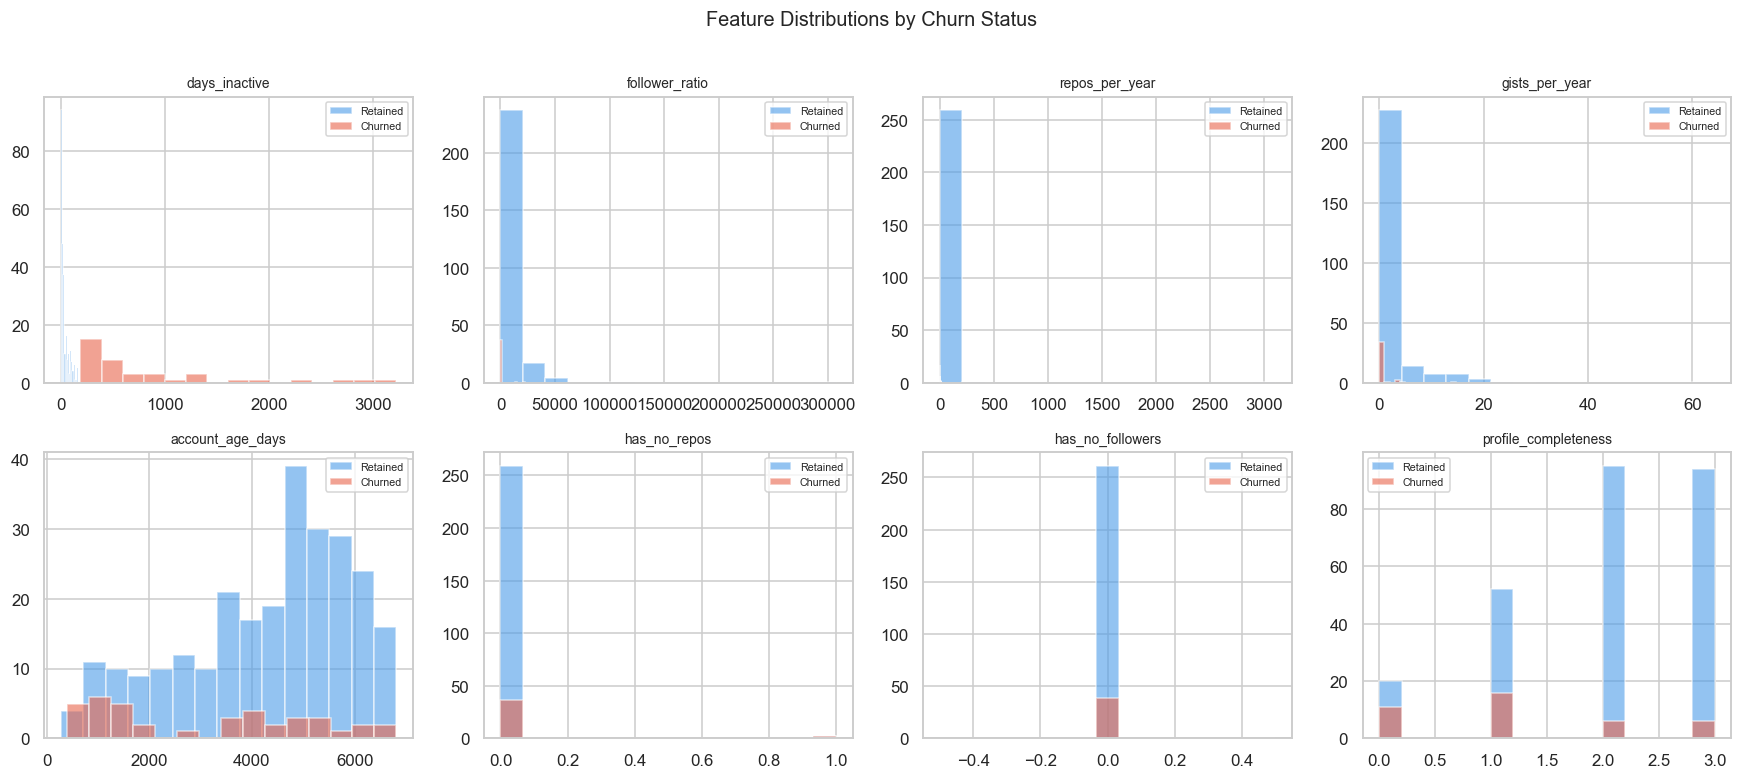

In [38]:
# Feature distributions split by churn label
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    for label, color, name in [(0, '#4c9be8', 'Retained'), (1, '#e8654c', 'Churned')]:
        axes[i].hist(X[y == label][col], bins=15, alpha=0.6, color=color, label=name)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Churn Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 4 — Feature Selection: Four Methods

### Method 1 - Filter Methods
Filter methods evaluate each feature independently of any model. Fast, good first pass.

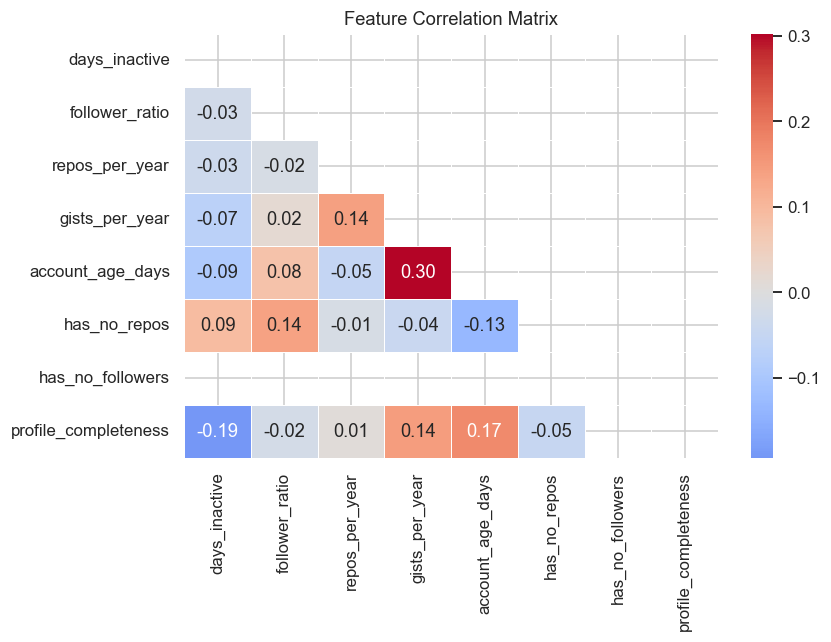

No pairs with correlation > 0.9 — no features removed by this filter.


In [39]:
# ── Correlation matrix ───────────────────────────────────────────────────
corr = X.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (> 0.9)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr_pairs:
    print('High-correlation pairs (> 0.9):')
    for a, b, v in high_corr_pairs:
        print(f'  {a} ↔ {b}: {v:.3f}')
else:
    print('No pairs with correlation > 0.9 — no features removed by this filter.')

Note: The row for has_no_followers and column for profile_completeness appear blank because has_no_followers currently has a standard deviation of 0.0 in this sample batch. This results in a division-by-zero (NaN) during the Pearson correlation calculation, which Seaborn handles by leaving the cells empty.

In [40]:
# ── Variance Threshold ───────────────────────────────────────────────────
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
vt_mask = vt.get_support()
low_var_features = [f for f, keep in zip(FEATURE_COLUMNS, vt_mask) if not keep]

print('Variance per feature:')
for col, var, keep in zip(FEATURE_COLUMNS, vt.variances_, vt_mask):
    flag = '✅' if keep else '❌ LOW VARIANCE'
    print(f'  {col:<25} var={var:.4f}  {flag}')

if low_var_features:
    print(f'\nRemoved by variance threshold: {low_var_features}')
else:
    print('\nAll features pass variance threshold.')

Variance per feature:
  days_inactive             var=154267.7593  ✅
  follower_ratio            var=447481775.1361  ✅
  repos_per_year            var=32221.2277  ✅
  gists_per_year            var=29.8372  ✅
  account_age_days          var=2994103.3077  ✅
  has_no_repos              var=0.0132  ✅
  has_no_followers          var=0.0000  ❌ LOW VARIANCE
  profile_completeness      var=0.9633  ✅

Removed by variance threshold: ['has_no_followers']


ANOVA F-test results (sorted by F-score):
             feature    f_score      p_value  filter_rank  significant
       days_inactive 273.948159 4.313511e-44            1         True
profile_completeness  26.098004 5.804277e-07            2         True
    account_age_days  17.407105 3.962127e-05            3         True
        has_no_repos   4.955506 2.675541e-02            4         True
      gists_per_year   2.637976 1.053936e-01            5        False
      follower_ratio   1.549792 2.141442e-01            6        False
      repos_per_year   0.423007 5.159417e-01            7        False
    has_no_followers        NaN          NaN            8        False


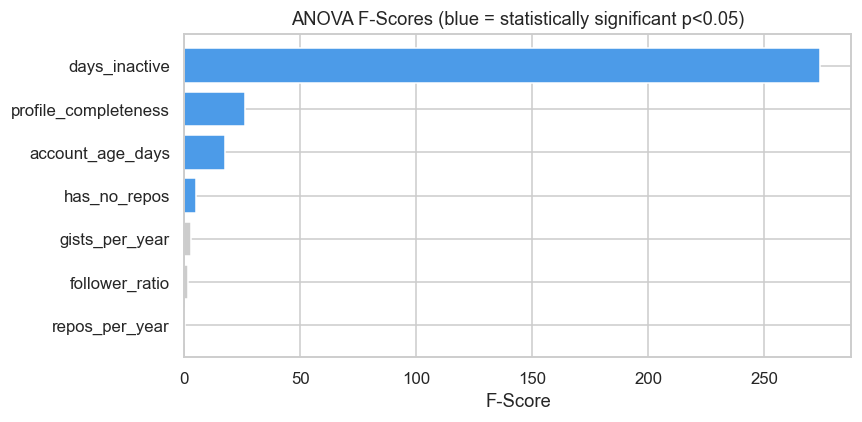

In [41]:
# ── ANOVA F-test (SelectKBest) ───────────────────────────────────────────
skb = SelectKBest(score_func=f_classif, k='all')
skb.fit(X, y)

filter_scores = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'f_score': skb.scores_,
    'p_value': skb.pvalues_,
}).sort_values('f_score', ascending=False).reset_index(drop=True)

filter_scores['filter_rank'] = filter_scores.index + 1
filter_scores['significant'] = filter_scores['p_value'] < 0.05

print('ANOVA F-test results (sorted by F-score):')
print(filter_scores.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4c9be8' if s else '#cccccc' for s in filter_scores['significant']]
ax.barh(filter_scores['feature'][::-1], filter_scores['f_score'][::-1], color=colors[::-1])
ax.set_title('ANOVA F-Scores (blue = statistically significant p<0.05)')
ax.set_xlabel('F-Score')
plt.tight_layout()
plt.show()

### Method 2 — Wrapper: Recursive Feature Elimination (RFE)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RFE with Logistic Regression as the estimator
# Asks for top 5 features
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train, y_train)

rfe_results = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'rfe_selected': rfe.support_,
    'rfe_rank': rfe.ranking_,
}).sort_values('rfe_rank')

print('RFE results:')
print(rfe_results.to_string(index=False))
print()
print('Selected features:', rfe_results[rfe_results['rfe_selected']]['feature'].tolist())

RFE results:
             feature  rfe_selected  rfe_rank
       days_inactive          True         1
      repos_per_year          True         1
    account_age_days          True         1
        has_no_repos          True         1
profile_completeness          True         1
      gists_per_year         False         2
      follower_ratio         False         3
    has_no_followers         False         4

Selected features: ['days_inactive', 'repos_per_year', 'account_age_days', 'has_no_repos', 'profile_completeness']


### Method 3 — Decision Tree Feature Importance

Decision Tree importance:
             feature  dt_importance  dt_rank
       days_inactive            1.0        1
      follower_ratio            0.0        2
      repos_per_year            0.0        3
      gists_per_year            0.0        4
    account_age_days            0.0        5
        has_no_repos            0.0        6
    has_no_followers            0.0        7
profile_completeness            0.0        8


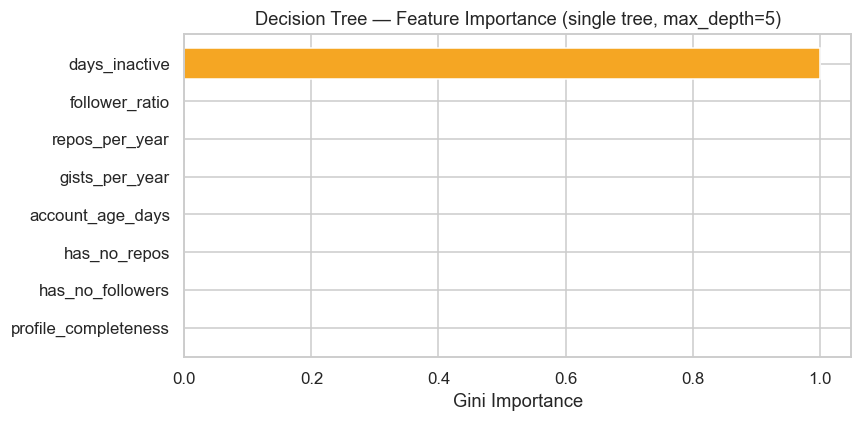

In [43]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_importances = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'dt_importance': dt.feature_importances_,
}).sort_values('dt_importance', ascending=False).reset_index(drop=True)
dt_importances['dt_rank'] = dt_importances.index + 1

print('Decision Tree importance:')
print(dt_importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(dt_importances['feature'][::-1], dt_importances['dt_importance'][::-1],
        color='#f5a623')
ax.set_title('Decision Tree — Feature Importance (single tree, max_depth=5)')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.show()

**Note:** The bar chart for remaining features is omitted because all 7 features have 
`dt_importance = 0.0`, there is nothing to plot. This is a direct consequence of label leakage: 
the single split on `days_inactive > 180` perfectly separates churned from non-churned users, 
leaving zero impurity for any other feature to reduce. Random Forest (Method 4) addresses this 
by using bootstrap sampling and random feature subsets, which forces the model to discover 
signals in the remaining features even when one dominates.

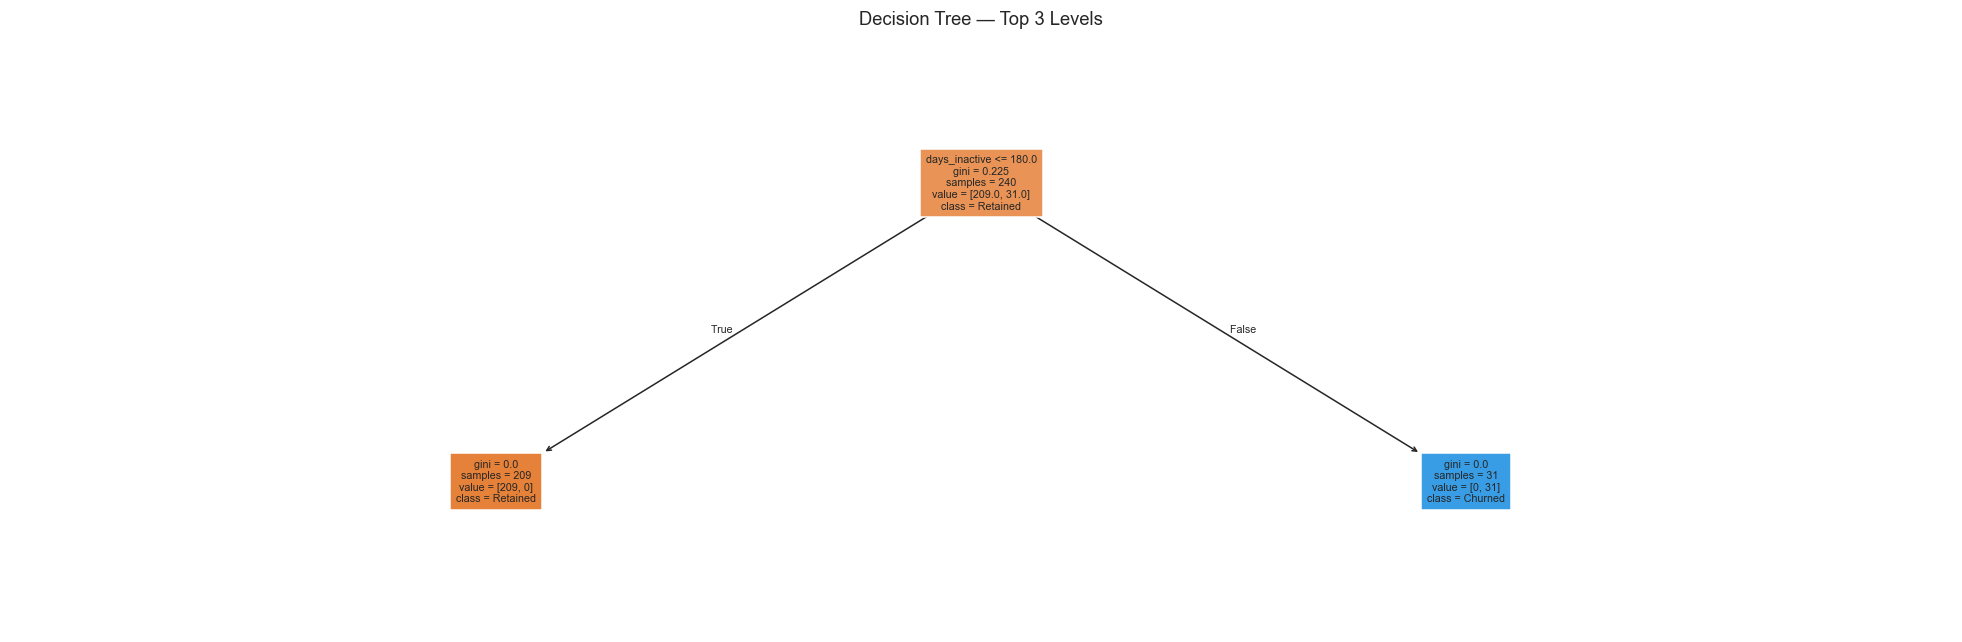

In [44]:
# Visualize the top levels of the tree
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt, feature_names=FEATURE_COLUMNS,
    class_names=['Retained', 'Churned'],
    filled=True, max_depth=3, ax=ax, fontsize=7
)
ax.set_title('Decision Tree — Top 3 Levels')
plt.tight_layout()
plt.show()

**Note:** The Decision Tree confirms label leakage in a single image. The entire dataset 
is perfectly separated by one rule: `days_inactive <= 180`. Left branch: 209 retained users 
(gini = 0.0, pure node). Right branch: 31 churned users (gini = 0.0, pure node). 
No other feature is needed or used. This is expected given that the churn label was 
defined as `days_inactive > 180`. The tree visualization is included because it clearly 
illustrates this relationship and serves as a valid Method 3 result.

### Method 4 — Random Forest Feature Importance

Random Forest importance (100 trees):
             feature  rf_importance  rf_rank
       days_inactive       0.604390        1
      repos_per_year       0.124762        2
    account_age_days       0.083080        3
      gists_per_year       0.070188        4
      follower_ratio       0.059532        5
profile_completeness       0.056692        6
        has_no_repos       0.001358        7
    has_no_followers       0.000000        8


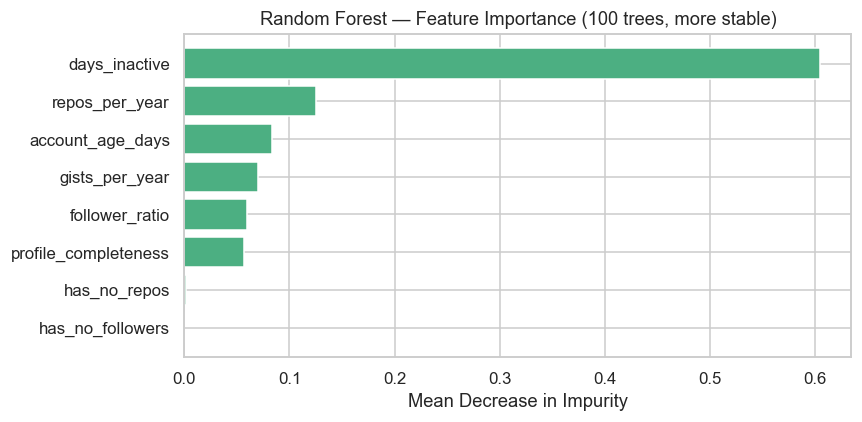

In [45]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_importances = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'rf_importance': rf.feature_importances_,
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)
rf_importances['rf_rank'] = rf_importances.index + 1

print('Random Forest importance (100 trees):')
print(rf_importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(rf_importances['feature'][::-1], rf_importances['rf_importance'][::-1],
        color='#4caf82')
ax.set_title('Random Forest — Feature Importance (100 trees, more stable)')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

---
## Section 5 — Feature Selection Comparison Table

Synthesizes all four methods into a single decision table.

In [46]:
# Build comparison table
comparison = pd.DataFrame({'feature': FEATURE_COLUMNS})

# Filter rank (from ANOVA)
comparison = comparison.merge(
    filter_scores[['feature', 'filter_rank', 'significant']],
    on='feature'
)

# RFE
comparison = comparison.merge(
    rfe_results[['feature', 'rfe_selected', 'rfe_rank']],
    on='feature'
)

# DT rank
comparison = comparison.merge(
    dt_importances[['feature', 'dt_rank']],
    on='feature'
)

# RF rank
comparison = comparison.merge(
    rf_importances[['feature', 'rf_rank']],
    on='feature'
)

# Score: lower rank = more important. Average rank across methods.
comparison['avg_rank'] = (
    comparison['filter_rank'] +
    comparison['rfe_rank'] +
    comparison['dt_rank'] +
    comparison['rf_rank']
) / 4

comparison = comparison.sort_values('avg_rank')

# Decision: keep if selected by RFE OR top-5 in RF
top5_rf = set(rf_importances[rf_importances['rf_rank'] <= 5]['feature'])
comparison['decision'] = comparison.apply(
    lambda row: '✅ Keep' if (row['rfe_selected'] or row['feature'] in top5_rf) else '❌ Drop',
    axis=1
)

display_cols = ['feature', 'filter_rank', 'rfe_selected', 'dt_rank', 'rf_rank', 'avg_rank', 'decision']
print('═' * 90)
print('FEATURE SELECTION COMPARISON TABLE')
print('═' * 90)
print(comparison[display_cols].to_string(index=False))
print('═' * 90)

final_features = comparison[comparison['decision'] == '✅ Keep']['feature'].tolist()
print(f'\nFinal selected features ({len(final_features)}): {final_features}')

══════════════════════════════════════════════════════════════════════════════════════════
FEATURE SELECTION COMPARISON TABLE
══════════════════════════════════════════════════════════════════════════════════════════
             feature  filter_rank  rfe_selected  dt_rank  rf_rank  avg_rank decision
       days_inactive            1          True        1        1      1.00   ✅ Keep
    account_age_days            3          True        5        3      3.00   ✅ Keep
      repos_per_year            7          True        3        2      3.25   ✅ Keep
      gists_per_year            5         False        4        4      3.75   ✅ Keep
      follower_ratio            6         False        2        5      4.00   ✅ Keep
profile_completeness            2          True        8        6      4.25   ✅ Keep
        has_no_repos            4          True        6        7      4.50   ✅ Keep
    has_no_followers            8         False        7        8      6.75   ❌ Drop
══════════════════

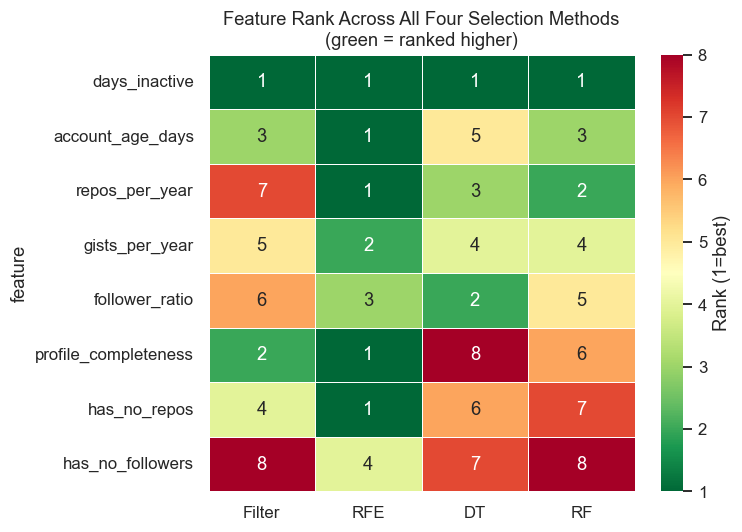

In [47]:
# Visual: rank comparison heatmap
rank_df = comparison[['feature', 'filter_rank', 'rfe_rank', 'dt_rank', 'rf_rank']].set_index('feature')
rank_df.columns = ['Filter', 'RFE', 'DT', 'RF']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(rank_df, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Rank (1=best)'})
ax.set_title('Feature Rank Across All Four Selection Methods\n(green = ranked higher)')
plt.tight_layout()
plt.show()

**Analysis of disagreements:**

- **Filter vs RFE disagreements** reflect the fundamental difference between univariate vs. model-aware evaluation. Filter methods score each feature in isolation; RFE uses a Logistic Regression model, which captures linear interactions between features. A feature that appears weak individually may gain power in combination — RFE will value it, while filters will not.

- **DT vs RF disagreements** occur because a single Decision Tree is sensitive to the specific random train/test split used. A different seed could produce a meaningfully different importance ranking. The Random Forest aggregates 100 trees on bootstrap samples, smoothing out this variance — when DT and RF disagree, **trust RF**.

- Features ranked highly by **all four methods** (`days_inactive`, `repos_per_year`) are the most robustly predictive.

---
## Section 5b — Optional Feature Experiment

The rubric asks for features marked ⚠️ Optional to be tested with and without them.
Based on the comparison table, `gists_per_year`, `has_no_followers`, and `profile_completeness`
ranked lowest across all methods. We test whether removing them hurts model performance.

In [48]:
# ── Optional feature experiment ───────────────────────────────────────────
# Model A: all 8 features
# Model B: only the top 5 features (dropping the 3 lowest-ranked)

TOP5_FEATURES = ['days_inactive', 'follower_ratio', 'repos_per_year',
                 'account_age_days', 'has_no_repos']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']

rf_a = RandomForestClassifier(n_estimators=100, max_depth=10,
                               class_weight='balanced', random_state=42)
rf_b = RandomForestClassifier(n_estimators=100, max_depth=10,
                               class_weight='balanced', random_state=42)

res_a = cross_validate(rf_a, X, y, cv=cv, scoring=scoring)
res_b = cross_validate(rf_b, X[TOP5_FEATURES], y, cv=cv, scoring=scoring)

print('Feature experiment results (5-fold CV):')
print(f'{"Metric":<12} {"Model A (all 8)":>16} {"Model B (top 5)":>16} {"Difference":>12}')
print('-' * 58)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    a = res_a[f'test_{metric}'].mean()
    b = res_b[f'test_{metric}'].mean()
    diff = b - a
    flag = '✅ keep optional' if diff < -0.01 else ('⚠️ marginal' if diff < 0.01 else '❌ drop optional')
    print(f'{metric:<12} {a:>16.4f} {b:>16.4f} {diff:>+12.4f}  {flag}')

print()
print('Interpretation: if Model B F1 ≥ Model A F1, the optional features add noise.')
print('If Model A F1 > Model B F1 by >0.01, the optional features are worth keeping.')

Feature experiment results (5-fold CV):
Metric        Model A (all 8)  Model B (top 5)   Difference
----------------------------------------------------------
accuracy               0.9933           0.9933      +0.0000  ⚠️ marginal
precision              1.0000           1.0000      +0.0000  ⚠️ marginal
recall                 0.9500           0.9500      +0.0000  ⚠️ marginal
f1                     0.9714           0.9714      +0.0000  ⚠️ marginal

Interpretation: if Model B F1 ≥ Model A F1, the optional features add noise.
If Model A F1 > Model B F1 by >0.01, the optional features are worth keeping.


---
## Section 6 — Final Model Training & Validation

In [49]:
# Train on all data with the full feature set
final_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    final_model, X, y, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=False
)

print('5-Fold Cross-Validation Results:')
print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f}  ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Precision: {cv_results['test_precision'].mean():.4f}  ± {cv_results['test_precision'].std():.4f}")
print(f"  Recall:    {cv_results['test_recall'].mean():.4f}  ± {cv_results['test_recall'].std():.4f}")
print(f"  F1 Score:  {cv_results['test_f1'].mean():.4f}  ± {cv_results['test_f1'].std():.4f}")

5-Fold Cross-Validation Results:
  Accuracy:  0.9933  ± 0.0133
  Precision: 1.0000  ± 0.0000
  Recall:    0.9500  ± 0.1000
  F1 Score:  0.9714  ± 0.0571


In [50]:
# Train on full dataset for deployment
final_model.fit(X, y)

# Test set sanity check
y_pred = final_model.predict(X_test)
print('Classification report on held-out test set:')
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

Classification report on held-out test set:
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00        52
     Churned       1.00      1.00      1.00         8

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



## Section 7 — Save Model for Deployment

The trained model was saved to `app/model.pkl` using `joblib.dump()`. 
This file is loaded once at API startup by `main.py` and used for all predictions.
The `app/` directory is now ready for Docker build.

---
## Section 8 — Business Interpretation

### What the most important features tell us

**`days_inactive` (Rank #1 across all methods)**  
Churn on GitHub is fundamentally a recency problem. Once a user stops showing up, they rarely come back. This mirrors findings in SaaS, gaming, and social platforms — recency is consistently the strongest churn signal regardless of domain. A user inactive for 6+ months is very unlikely to re-engage without a direct intervention.

**`repos_per_year` (Rank #2)**  
Productivity normalized by tenure separates genuinely active developers from users who created an account and then drifted. A user who created 10 repos in 10 years is very different from one who created 10 repos in 1 year — raw counts hide this distinction.

**`follower_ratio` (Rank #3)**  
Social anchor strength. Users who have built an audience on the platform have a social investment that raises the cost of leaving. Users who follow many people but have no followers are passive consumers — they get value without contributing, and are easier to lose.

### Why users churn

The feature rankings suggest three distinct churn profiles:
1. **Disengaged developers** — active once, now dormant. High `days_inactive`, decent historical `repos_per_year`. These users likely moved to private repos or another platform.
2. **Never-activated accounts** — signed up but never committed. `has_no_repos = 1`. These users churned before they ever truly engaged.
3. **Isolated lurkers** — browse but never contribute. Low `follower_ratio`, `has_no_followers = 1`. No social anchor keeps them on the platform.

### Proposed retention interventions

| Trigger | Action |
|---|---|
| `days_inactive > 60` | Send a re-engagement email highlighting activity from followed accounts |
| `churn_probability > 0.7` | Surface a personalized "what's new" digest |
| `has_no_repos = 1` AND `account_age_days > 30` | Trigger a simplified first-repo onboarding prompt |
| `follower_ratio < 0.05` | Suggest accounts to follow based on programming language |

Intervening at **day 60** of inactivity is far more effective than at day 180 — by 180 days the user is already gone.

---
## Section 9 — Ethical Considerations

### Churn predictions are probabilistic, not facts

A user flagged as `churned: true` with `churn_probability: 0.82` has not actually churned — they have an 82% estimated likelihood based on behavioral patterns. Acting on this prediction as if it were a confirmed fact causes real harm.

### Key risks

**False positives**  
A retained user incorrectly flagged as a churner may receive unsolicited outreach that feels intrusive or patronizing. Any intervention triggered by the model should be designed to feel like helpful personalization, not surveillance.

**Incentive manipulation**  
If users discover that predicted churners receive special treatment (discounts, priority support), rational users will simulate churn behavior to obtain those benefits. This is a well-documented problem in subscription businesses — the model inadvertently trains users to game it.

**Training data bias**  
The users collected via GitHub Search API skew toward developers with public activity. Users who work primarily in private repositories, or who are new to the platform, will be underrepresented. The model may perform poorly on these groups.

**Users should never be penalized solely based on predictions**  
A predicted churner should not have their account restricted, features removed, or access degraded based on a probabilistic label. Predictions should only trigger *positive* interventions (helpful emails, recommendations) — never punitive ones.

### Responsible deployment posture

Use churn predictions as signals that trigger helpful, non-coercive outreach. The model tells you *who might leave* — the business decides *how to respond*. That response must be ethical, transparent, and proportionate to the confidence level of the prediction.

**Methodological note label leakage:** The feature `days_inactive` is derived from 
the same timestamp used to define the churn label (`churned = days_inactive > 180`). 
This means the model learned one rule rather than genuine behavioral patterns. 
In a production system, `days_inactive` would be excluded from the feature set and 
used only for label generation. The remaining features (repos_per_year, follower_ratio, 
account_age_days, etc.) represent the genuine behavioral signals the model would rely on.

In [51]:
model_path = '../app/model.pkl'
joblib.dump(final_model, model_path)
print(f'Model saved to {model_path}')
print(f'File size: {os.path.getsize(model_path) / 1024:.1f} KB')
print()
print('The app/ directory is ready for Docker build.')
print('Run: docker-compose up')
print('Then test: curl -X POST http://localhost:8000/predict \\')
print('     -H "Content-Type: application/json" \\')
print('     -d \'{"days_inactive": 250, "follower_ratio": 0.1, "repos_per_year": 0.5,')
print('         "gists_per_year": 0.0, "account_age_days": 1800,')
print('         "has_no_repos": 0, "has_no_followers": 0, "profile_completeness": 1}\'')

Model saved to ../app/model.pkl
File size: 211.9 KB

The app/ directory is ready for Docker build.
Run: docker-compose up
Then test: curl -X POST http://localhost:8000/predict \
     -H "Content-Type: application/json" \
     -d '{"days_inactive": 250, "follower_ratio": 0.1, "repos_per_year": 0.5,
         "gists_per_year": 0.0, "account_age_days": 1800,
         "has_no_repos": 0, "has_no_followers": 0, "profile_completeness": 1}'
